# COVID-19 Global Impact Analysis

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [34]:
df = pd.read_csv("CovidData.csv")
df

,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,gdp_per_capita,extreme_poverty,cardiovasc_death_rate,diabetes_prevalence,female_smokers,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index
0,AFG,Asia,Afghanistan,24-02-2020,1.0,1.0,NaN,NaN,NaN,NaN,...,1803.987,NaN,597.029,9.59,NaN,NaN,37.746,0.5,64.83,0.511
1,AFG,Asia,Afghanistan,25-02-2020,1.0,0.0,NaN,NaN,NaN,NaN,...,1803.987,NaN,597.029,9.59,NaN,NaN,37.746,0.5,64.83,0.511
2,AFG,Asia,Afghanistan,26-02-2020,1.0,0.0,NaN,NaN,NaN,NaN,...,1803.987,NaN,597.029,9.59,NaN,NaN,37.746,0.5,64.83,0.511
3,AFG,Asia,Afghanistan,27-02-2020,1.0,0.0,NaN,NaN,NaN,NaN,...,1803.987,NaN,597.029,9.59,NaN,NaN,37.746,0.5,64.83,0.511
4,AFG,Asia,Afghanistan,28-02-2020,1.0,0.0,NaN,NaN,NaN,NaN,...,1803.987,NaN,597.029,9.59,NaN,NaN,37.746,0.5,64.83,0.511
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85166,ZWE,Africa,Zimbabwe,26-04-2021,38102.0,16.0,34.714,1560.0,3.0,1.000,...,1899.775,21.4,307.846,1.82,1.6,30.7,36.791,1.7,61.49,0.571
85167,ZWE,Africa,Zimbabwe,27-04-2021,38164.0,62.0,41.286,1565.0,5.0,1.571,...,1899.775,21.4,307.846,1.82,1.6,30.7,36.791,1.7,61.49,0.571
85168,ZWE,Africa,Zimbabwe,28-04-2021,38191.0,27.0,30.143,1565.0,0.0,1.429,...,1899.775,21.4,307.846,1.82,1.6,30.7,36.791,1.7,61.49,0.571
85169,ZWE,Africa,Zimbabwe,29-04-2021,38235.0,44.0,31.000,1567.0,2.0,1.714,...,1899.775,21.4,307.846,1.82,1.6,30.7,36.791,1.7,61.49,0.571


## COVID-19 Global Impact Analysis: Cases & Deaths

In [35]:
df_cleaned = df[(df['continent'].notna()) & (df['continent'] != '')]
df_cleaned

,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,gdp_per_capita,extreme_poverty,cardiovasc_death_rate,diabetes_prevalence,female_smokers,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index
0,AFG,Asia,Afghanistan,24-02-2020,1.0,1.0,NaN,NaN,NaN,NaN,...,1803.987,NaN,597.029,9.59,NaN,NaN,37.746,0.5,64.83,0.511
1,AFG,Asia,Afghanistan,25-02-2020,1.0,0.0,NaN,NaN,NaN,NaN,...,1803.987,NaN,597.029,9.59,NaN,NaN,37.746,0.5,64.83,0.511
2,AFG,Asia,Afghanistan,26-02-2020,1.0,0.0,NaN,NaN,NaN,NaN,...,1803.987,NaN,597.029,9.59,NaN,NaN,37.746,0.5,64.83,0.511
3,AFG,Asia,Afghanistan,27-02-2020,1.0,0.0,NaN,NaN,NaN,NaN,...,1803.987,NaN,597.029,9.59,NaN,NaN,37.746,0.5,64.83,0.511
4,AFG,Asia,Afghanistan,28-02-2020,1.0,0.0,NaN,NaN,NaN,NaN,...,1803.987,NaN,597.029,9.59,NaN,NaN,37.746,0.5,64.83,0.511
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85166,ZWE,Africa,Zimbabwe,26-04-2021,38102.0,16.0,34.714,1560.0,3.0,1.000,...,1899.775,21.4,307.846,1.82,1.6,30.7,36.791,1.7,61.49,0.571
85167,ZWE,Africa,Zimbabwe,27-04-2021,38164.0,62.0,41.286,1565.0,5.0,1.571,...,1899.775,21.4,307.846,1.82,1.6,30.7,36.791,1.7,61.49,0.571
85168,ZWE,Africa,Zimbabwe,28-04-2021,38191.0,27.0,30.143,1565.0,0.0,1.429,...,1899.775,21.4,307.846,1.82,1.6,30.7,36.791,1.7,61.49,0.571
85169,ZWE,Africa,Zimbabwe,29-04-2021,38235.0,44.0,31.000,1567.0,2.0,1.714,...,1899.775,21.4,307.846,1.82,1.6,30.7,36.791,1.7,61.49,0.571


In [36]:
cases_deaths = df_cleaned.groupby(['location'])[['new_cases', 'new_deaths']].sum().reset_index()
cases_deaths.columns = ['Country','Cases','Deaths']
cases_deaths

,Country,Cases,Deaths
0,Afghanistan,59745.0,2625.0
1,Albania,131085.0,2394.0
2,Algeria,122108.0,3253.0
3,Andorra,13232.0,125.0
4,Angola,26652.0,596.0
...,...,...,...
205,Venezuela,197683.0,2136.0
206,Vietnam,2928.0,35.0
207,Yemen,6317.0,1226.0
208,Zambia,91586.0,1251.0


## Top 20 Countries by Total COVID-19 Cases

In [37]:
cases = cases_deaths.nlargest(20,'Cases')
cases = cases[['Country', 'Cases']]
cases = cases.reset_index(drop=True)
cases

,Country,Cases
0,United States,32346970.0
1,India,19164969.0
2,Brazil,14659011.0
3,France,5677835.0
4,Russia,4750755.0
5,United Kingdom,4432246.0
6,Italy,4022653.0
7,Turkey,3997366.0
8,Spain,3524077.0
9,Germany,3405365.0


## Top 20 Countries with highest Covid-19 death toll

In [38]:
deaths = cases_deaths.nlargest(20,'Deaths')
deaths = deaths[['Country','Deaths']]
deaths = deaths.reset_index(drop=True)
deaths

,Country,Deaths
0,United States,576232.0
1,Brazil,403781.0
2,Mexico,216907.0
3,India,211853.0
4,United Kingdom,127775.0
5,Italy,120807.0
6,Russia,108290.0
7,France,104675.0
8,Germany,83097.0
9,Spain,78216.0


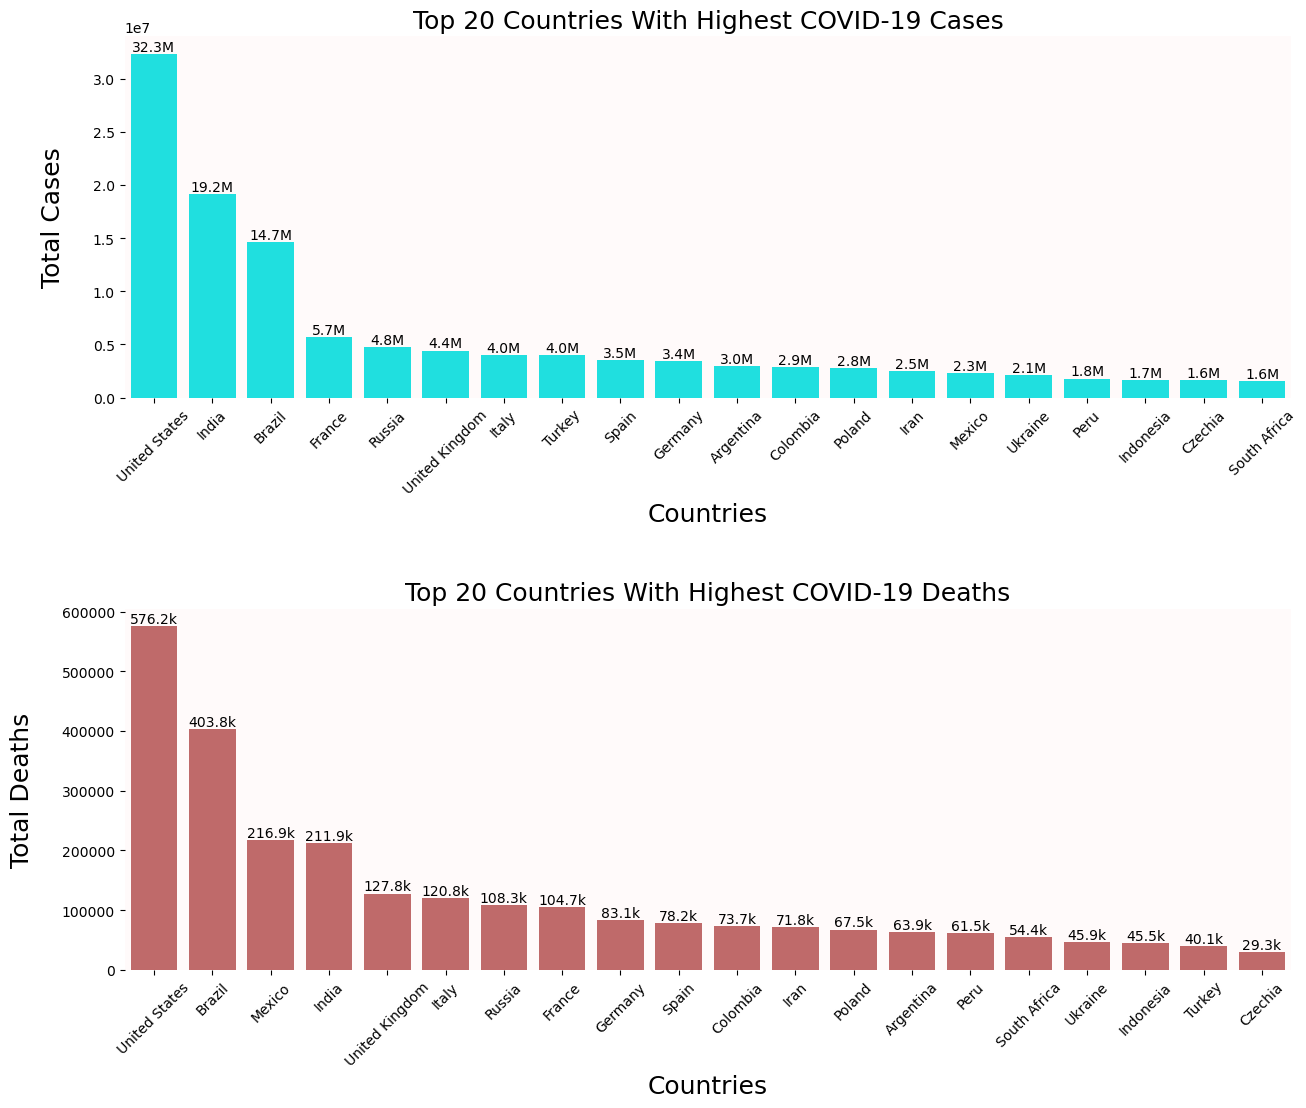

In [40]:
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(14, 12))

bars = sns.barplot(ax=axes[0],data=cases,
            x='Country',
            y='Cases',
            color='Aqua'
           )
axes[0].tick_params(axis='x',rotation=45)
axes[0].set_xlabel('Countries',fontsize=18)
axes[0].set_ylabel('Total Cases',fontsize=18,labelpad=20)
axes[0].set_title("Top 20 Countries With Highest COVID-19 Cases",fontsize=18)
axes[0].set_facecolor('snow')


for bar in bars.patches:
    height = bar.get_height()
    bars.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height/1e6:.1f}M',  
        ha='center',
        va='bottom',
        fontsize=10
    )

bars = sns.barplot(ax=axes[1],data=deaths,
            x='Country',
            y='Deaths',
            color='indianred'
           )

axes[1].tick_params(axis='x',rotation=45)
axes[1].set_xlabel('Countries',fontsize=18)
axes[1].set_ylabel('Total Deaths',fontsize=18,labelpad=20)
axes[1].set_title("Top 20 Countries With Highest COVID-19 Deaths",fontsize=18)
axes[1].set_facecolor('snow')


for bar in bars.patches:
    height = bar.get_height()
    bars.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height/1e3:.1f}k',  
        ha='center',
        va='bottom',
        fontsize=10
    )
plt.subplots_adjust(hspace=0.6)

for ax in axes:
    for spine in ['top', 'right', 'left', 'bottom']:
        ax.spines[spine].set_visible(False)

plt.tight_layout(pad=4)
plt.show()

## Covid-19 Cases and Deaths Across Continents

In [41]:
continent_cases_deaths = df.groupby(['continent'])[['new_cases','new_deaths']].sum().reset_index()
continent_cases_deaths.columns = ['Continents','Cases','Deaths']
continent_cases_deaths

,Continents,Cases,Deaths
0,Africa,4557699.0,121784.0
1,Asia,38702527.0,520269.0
2,Europe,44863478.0,1016750.0
3,North America,37529487.0,847942.0
4,Oceania,43570.0,1046.0
5,South America,24878216.0,672415.0


### Covid-19 Cases across Continents

In [42]:
continent_cases = continent_cases_deaths[['Continents','Cases']]
continent_cases

,Continents,Cases
0,Africa,4557699.0
1,Asia,38702527.0
2,Europe,44863478.0
3,North America,37529487.0
4,Oceania,43570.0
5,South America,24878216.0


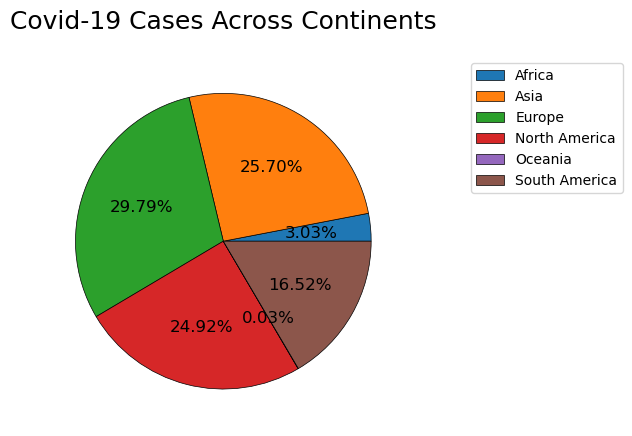

In [45]:
wedges, texts, autotexts=plt.pie(continent_cases['Cases'],
                                 autopct='%1.2f%%',
                                 wedgeprops={'edgecolor': 'black', 
                                             'linewidth': 0.5}
                                )

        
for autotext in autotexts:
    autotext.set_fontsize(12)


plt.legend(wedges,
           continent_cases['Continents'],
          loc='upper right',
          bbox_to_anchor=(1.6, 1))

plt.title("Covid-19 Cases Across Continents",fontsize=18,pad=20)
plt.show()

## Percentage Distribution Of Deaths due to Covid across Continents 

In [46]:
continent_deaths = continent_cases_deaths[['Continents','Deaths']]
continent_deaths

,Continents,Deaths
0,Africa,121784.0
1,Asia,520269.0
2,Europe,1016750.0
3,North America,847942.0
4,Oceania,1046.0
5,South America,672415.0


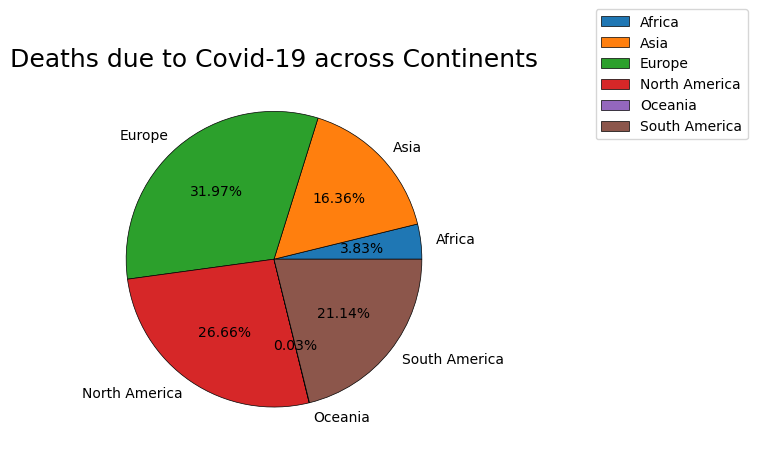

In [47]:
plt.pie(continent_deaths['Deaths'],
        labels=continent_deaths['Continents'],
        autopct='%1.2f%%',
       wedgeprops={'edgecolor':'black','linewidth':0.5}
       )

plt.legend(loc='right',
          bbox_to_anchor=(1.8,1))

plt.title('Deaths due to Covid-19 across Continents',fontsize=18)

plt.show()

## Covid-19 Cases and Deaths across Asia

In [48]:
asia_df = df[df['continent']=='Asia']
asia_df

,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,gdp_per_capita,extreme_poverty,cardiovasc_death_rate,diabetes_prevalence,female_smokers,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index
0,AFG,Asia,Afghanistan,24-02-2020,1.0,1.0,NaN,NaN,NaN,NaN,...,1803.987,NaN,597.029,9.59,NaN,NaN,37.746,0.5,64.83,0.511
1,AFG,Asia,Afghanistan,25-02-2020,1.0,0.0,NaN,NaN,NaN,NaN,...,1803.987,NaN,597.029,9.59,NaN,NaN,37.746,0.5,64.83,0.511
2,AFG,Asia,Afghanistan,26-02-2020,1.0,0.0,NaN,NaN,NaN,NaN,...,1803.987,NaN,597.029,9.59,NaN,NaN,37.746,0.5,64.83,0.511
3,AFG,Asia,Afghanistan,27-02-2020,1.0,0.0,NaN,NaN,NaN,NaN,...,1803.987,NaN,597.029,9.59,NaN,NaN,37.746,0.5,64.83,0.511
4,AFG,Asia,Afghanistan,28-02-2020,1.0,0.0,NaN,NaN,NaN,NaN,...,1803.987,NaN,597.029,9.59,NaN,NaN,37.746,0.5,64.83,0.511
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84350,YEM,Asia,Yemen,26-04-2021,6183.0,46.0,46.429,1205.0,18.0,10.429,...,1479.147,18.8,495.003,5.35,7.6,29.2,49.542,0.7,66.12,0.470
84351,YEM,Asia,Yemen,27-04-2021,6220.0,37.0,43.143,1207.0,2.0,9.857,...,1479.147,18.8,495.003,5.35,7.6,29.2,49.542,0.7,66.12,0.470
84352,YEM,Asia,Yemen,28-04-2021,6263.0,43.0,43.286,1216.0,9.0,9.857,...,1479.147,18.8,495.003,5.35,7.6,29.2,49.542,0.7,66.12,0.470
84353,YEM,Asia,Yemen,29-04-2021,6294.0,31.0,39.143,1222.0,6.0,9.286,...,1479.147,18.8,495.003,5.35,7.6,29.2,49.542,0.7,66.12,0.470


In [50]:
cases_deaths_asia = asia_df.groupby(['location'])[['new_cases','new_deaths']].sum().reset_index()
cases_deaths_asia.columns = ['Country','Cases','Deaths']
cases_deaths_asia

,Country,Cases,Deaths
0,Afghanistan,59745.0,2625.0
1,Armenia,216064.0,4108.0
2,Azerbaijan,319109.0,4517.0
3,Bahrain,176934.0,646.0
4,Bangladesh,759132.0,11450.0
5,Bhutan,1074.0,1.0
6,Brunei,224.0,3.0
7,Cambodia,13402.0,93.0
8,China,101946.0,4828.0
9,Georgia,310310.0,4110.0


## Top 20 Asian Countries with maximum Covid-19 Cases

In [51]:
cases_asia = cases_deaths_asia[['Country','Cases']]
cases_asia = cases_asia.nlargest(20,'Cases')
cases_asia = cases_asia.reset_index(drop=True)
cases_asia

,Country,Cases
0,India,19164969.0
1,Turkey,3997366.0
2,Iran,2499077.0
3,Indonesia,1668368.0
4,Iraq,1065199.0
5,Philippines,1037460.0
6,Israel,838481.0
7,Pakistan,825519.0
8,Bangladesh,759132.0
9,Jordan,711373.0


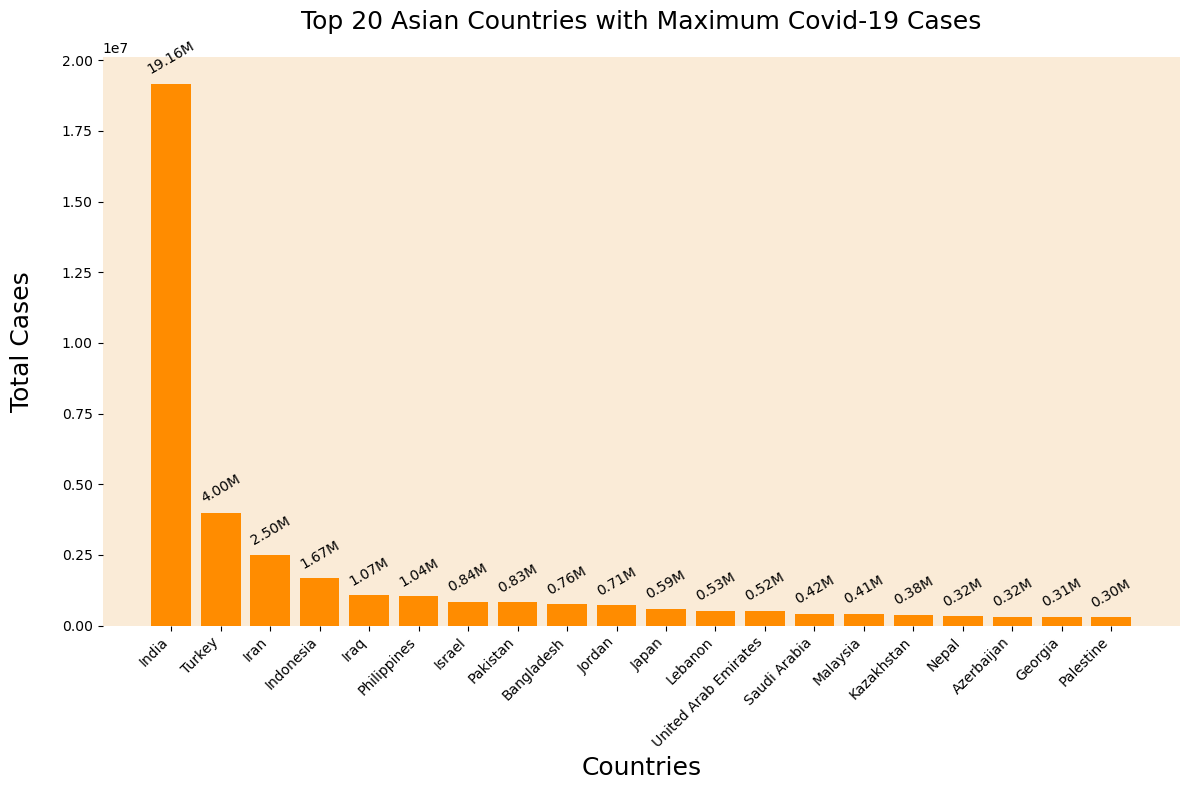

In [67]:
plt.figure(figsize=(12,8))

bars=plt.bar(cases_asia['Country'],cases_asia['Cases'],color="darkorange")

ax=plt.gca()
for spine in ['top','right','left','bottom']:
    ax.spines[spine].set_visible(False)
    
plt.xticks(rotation=45,ha='right')
plt.title("Top 20 Asian Countries with Maximum Covid-19 Cases",fontsize=18,pad=20)
plt.xlabel("Countries",fontsize=18)
plt.ylabel("Total Cases",fontsize=18,labelpad=20)
ax.set_facecolor('antiquewhite')


plt.bar_label(bars,labels=[f'{val/1e6:.2f}M' for val in cases_asia['Cases']], fontsize=10,padding=5,rotation=30)

plt.tight_layout()
plt.show()

## Top 20 Asian Countries with maximum Deaths due to Covid-19

In [68]:
deaths_asia = cases_deaths_asia[['Country','Deaths']]
deaths_asia = deaths_asia.nlargest(20,'Deaths')
deaths_asia = deaths_asia.reset_index(drop=True)
deaths_asia

,Country,Deaths
0,India,211853.0
1,Iran,71758.0
2,Indonesia,45521.0
3,Turkey,40131.0
4,Pakistan,17957.0
5,Philippines,17234.0
6,Iraq,15465.0
7,Bangladesh,11450.0
8,Japan,10199.0
9,Jordan,8836.0


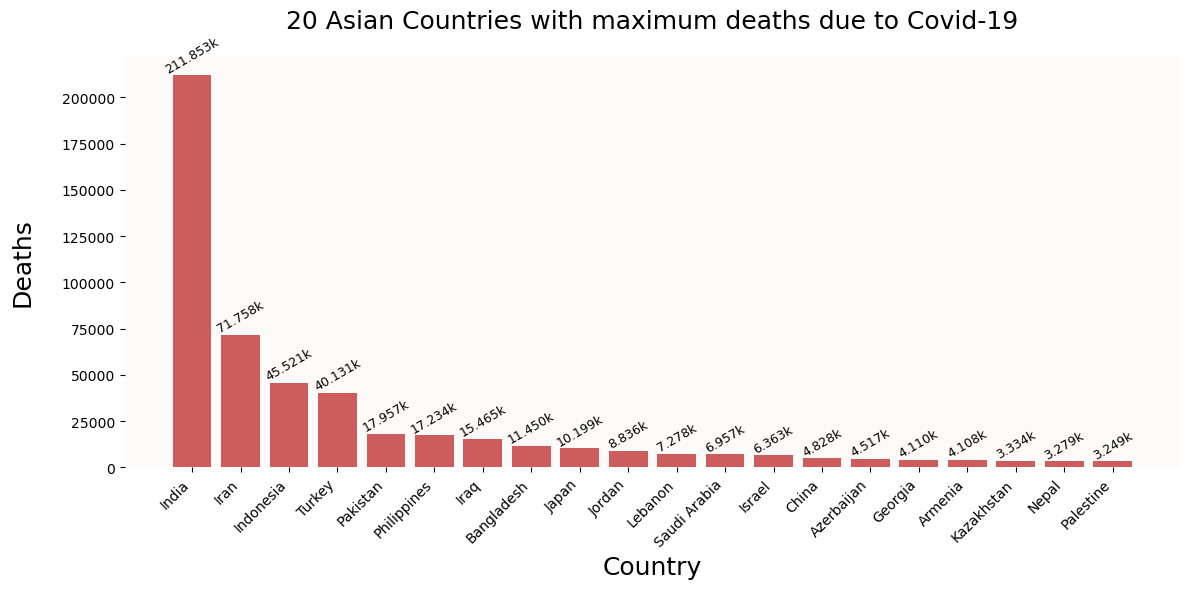

In [72]:
plt.figure(figsize=(12,6))
bars=plt.bar(deaths_asia['Country'],deaths_asia['Deaths'],color="indianred")

ax=plt.gca()
for spine in ['top','right','bottom','left']:
    ax.spines[spine].set_visible(False)

ax.set_facecolor('snow')
plt.title("20 Asian Countries with maximum deaths due to Covid-19",fontsize=18,pad=20)
plt.xlabel("Country",fontsize=18)
plt.ylabel("Deaths",fontsize=18,labelpad=20)
plt.xticks(rotation=45,ha='right')
plt.tight_layout()


plt.bar_label(bars, labels=[f'{val/1e3:.3f}k' for val in deaths_asia['Deaths']], fontsize=9,rotation=30)
plt.show()

## Covid-19 cases and deaths analysis in Asia

In [73]:
asia_df2 = df[df['continent']=='Asia'].copy()
asia_df2

,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,gdp_per_capita,extreme_poverty,cardiovasc_death_rate,diabetes_prevalence,female_smokers,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index
0,AFG,Asia,Afghanistan,24-02-2020,1.0,1.0,NaN,NaN,NaN,NaN,...,1803.987,NaN,597.029,9.59,NaN,NaN,37.746,0.5,64.83,0.511
1,AFG,Asia,Afghanistan,25-02-2020,1.0,0.0,NaN,NaN,NaN,NaN,...,1803.987,NaN,597.029,9.59,NaN,NaN,37.746,0.5,64.83,0.511
2,AFG,Asia,Afghanistan,26-02-2020,1.0,0.0,NaN,NaN,NaN,NaN,...,1803.987,NaN,597.029,9.59,NaN,NaN,37.746,0.5,64.83,0.511
3,AFG,Asia,Afghanistan,27-02-2020,1.0,0.0,NaN,NaN,NaN,NaN,...,1803.987,NaN,597.029,9.59,NaN,NaN,37.746,0.5,64.83,0.511
4,AFG,Asia,Afghanistan,28-02-2020,1.0,0.0,NaN,NaN,NaN,NaN,...,1803.987,NaN,597.029,9.59,NaN,NaN,37.746,0.5,64.83,0.511
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84350,YEM,Asia,Yemen,26-04-2021,6183.0,46.0,46.429,1205.0,18.0,10.429,...,1479.147,18.8,495.003,5.35,7.6,29.2,49.542,0.7,66.12,0.470
84351,YEM,Asia,Yemen,27-04-2021,6220.0,37.0,43.143,1207.0,2.0,9.857,...,1479.147,18.8,495.003,5.35,7.6,29.2,49.542,0.7,66.12,0.470
84352,YEM,Asia,Yemen,28-04-2021,6263.0,43.0,43.286,1216.0,9.0,9.857,...,1479.147,18.8,495.003,5.35,7.6,29.2,49.542,0.7,66.12,0.470
84353,YEM,Asia,Yemen,29-04-2021,6294.0,31.0,39.143,1222.0,6.0,9.286,...,1479.147,18.8,495.003,5.35,7.6,29.2,49.542,0.7,66.12,0.470


In [74]:
asia_df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20234 entries, 0 to 84354
Data columns (total 59 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   iso_code                               20234 non-null  object 
 1   continent                              20234 non-null  object 
 2   location                               20234 non-null  object 
 3   date                                   20234 non-null  object 
 4   total_cases                            19882 non-null  float64
 5   new_cases                              19876 non-null  float64
 6   new_cases_smoothed                     19647 non-null  float64
 7   total_deaths                           16864 non-null  float64
 8   new_deaths                             16863 non-null  float64
 9   new_deaths_smoothed                    19647 non-null  float64
 10  total_cases_per_million                19882 non-null  float64
 11  new_cas

In [75]:
asia_df2['date'] = pd.to_datetime(asia_df2['date'],format='%d-%m-%Y')
asia_df2['Month-Year'] = asia_df2['date'].dt.to_period('M').astype(str)
asia_monthly_cases_deaths = asia_df2.groupby(['Month-Year'])[['new_cases','new_deaths']].sum().reset_index()
asia_monthly_cases_deaths.rename(columns={'new_cases':'Cases','new_deaths':'Deaths'},inplace=True)
asia_monthly_cases_deaths

,Month-Year,Cases,Deaths
0,2020-01,9333.0,196.0
1,2020-02,73831.0,2691.0
2,2020-03,95313.0,4232.0
3,2020-04,341931.0,11570.0
4,2020-05,617814.0,12125.0
5,2020-06,1166426.0,26152.0
6,2020-07,1991314.0,39743.0
7,2020-08,2817359.0,45881.0
8,2020-09,3554777.0,52510.0
9,2020-10,3045973.0,48211.0


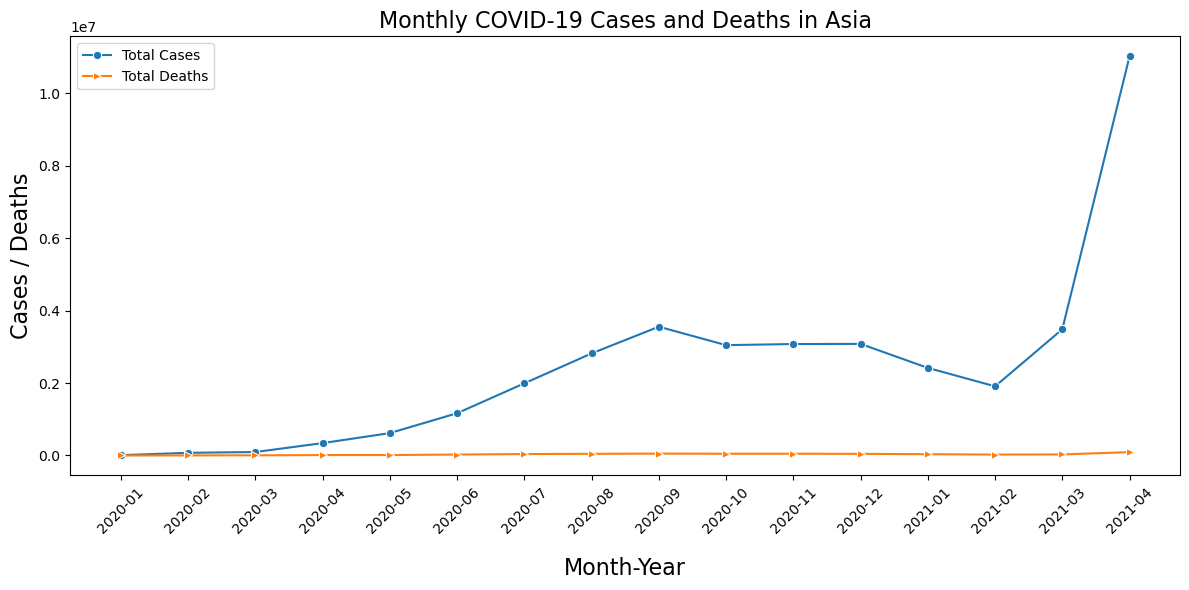

In [76]:
plt.figure(figsize=(12,6))
sns.lineplot(asia_monthly_cases_deaths,
             x='Month-Year',
             y='Cases',
            marker='o',
            label='Total Cases')

sns.lineplot(asia_monthly_cases_deaths,
             x='Month-Year',
             y='Deaths',
            marker='>',
            label='Total Deaths')

plt.title('Monthly COVID-19 Cases and Deaths in Asia',fontsize=16)
plt.xlabel('Month-Year',fontsize=16,labelpad=15)
plt.xticks(rotation=45)
plt.ylabel('Cases / Deaths',fontsize=16)
plt.tight_layout()
plt.show()

## Deaths due to Covid in Asia

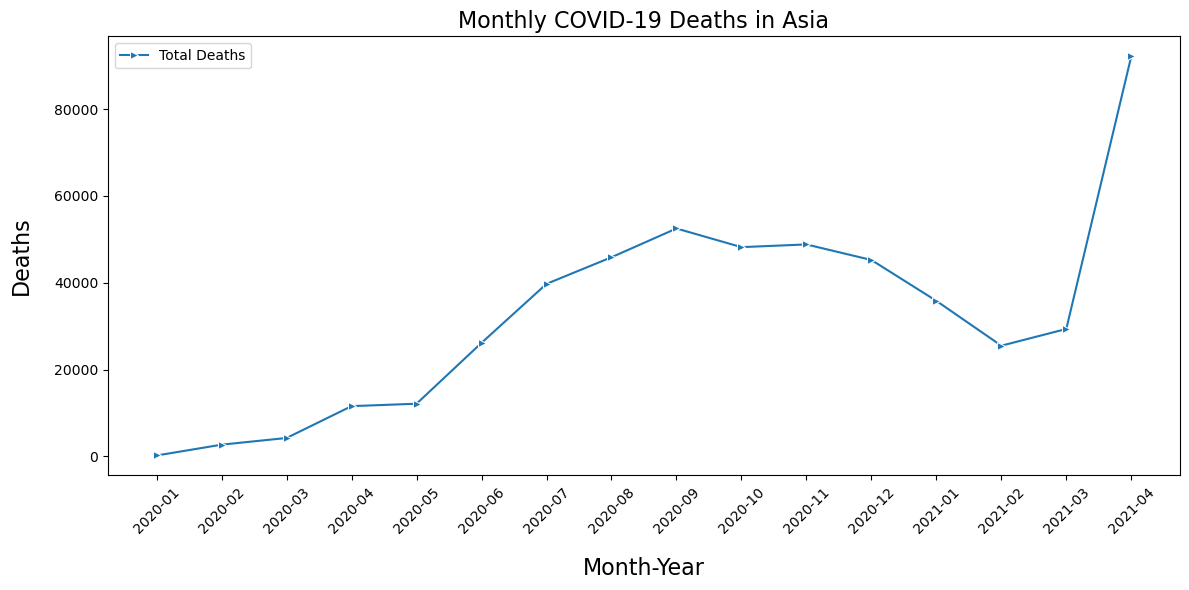

In [77]:
plt.figure(figsize=(12,6))
sns.lineplot(asia_monthly_cases_deaths,
             x='Month-Year',
             y='Deaths',
            marker='>',
            label='Total Deaths')

plt.title('Monthly COVID-19 Deaths in Asia',fontsize=16)
plt.xlabel('Month-Year',fontsize=16,labelpad=15)
plt.xticks(rotation=45)
plt.ylabel('Deaths',fontsize=16,labelpad=15)
plt.tight_layout()
plt.show()

## Covid-19 cases and deaths analysis in India 

In [78]:
india_df = df[df['location']=='India'].copy()
india_df

,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,gdp_per_capita,extreme_poverty,cardiovasc_death_rate,diabetes_prevalence,female_smokers,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index
35021,IND,Asia,India,30-01-2020,1.0,1.0,NaN,NaN,NaN,NaN,...,6426.674,21.2,282.28,10.39,1.9,20.6,59.55,0.53,69.66,0.645
35022,IND,Asia,India,31-01-2020,1.0,0.0,NaN,NaN,NaN,NaN,...,6426.674,21.2,282.28,10.39,1.9,20.6,59.55,0.53,69.66,0.645
35023,IND,Asia,India,01-02-2020,1.0,0.0,NaN,NaN,NaN,NaN,...,6426.674,21.2,282.28,10.39,1.9,20.6,59.55,0.53,69.66,0.645
35024,IND,Asia,India,02-02-2020,2.0,1.0,NaN,NaN,NaN,NaN,...,6426.674,21.2,282.28,10.39,1.9,20.6,59.55,0.53,69.66,0.645
35025,IND,Asia,India,03-02-2020,3.0,1.0,NaN,NaN,NaN,NaN,...,6426.674,21.2,282.28,10.39,1.9,20.6,59.55,0.53,69.66,0.645
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35473,IND,Asia,India,26-04-2021,17636186.0,323023.0,330744.857,197894.0,2771.0,2480.571,...,6426.674,21.2,282.28,10.39,1.9,20.6,59.55,0.53,69.66,0.645
35474,IND,Asia,India,27-04-2021,17997113.0,360927.0,340140.429,201187.0,3293.0,2662.000,...,6426.674,21.2,282.28,10.39,1.9,20.6,59.55,0.53,69.66,0.645
35475,IND,Asia,India,28-04-2021,18376421.0,379308.0,349378.143,204832.0,3645.0,2882.143,...,6426.674,21.2,282.28,10.39,1.9,20.6,59.55,0.53,69.66,0.645
35476,IND,Asia,India,29-04-2021,18762976.0,386555.0,357040.143,208330.0,3498.0,3058.571,...,6426.674,21.2,282.28,10.39,1.9,20.6,59.55,0.53,69.66,0.645


In [79]:
india_df['date']=pd.to_datetime(india_df['date'],format='%d-%m-%Y')
india_df['month-year'] = india_df['date'].dt.to_period('M').astype(str)
india_cases_deaths = india_df.groupby(['month-year'])[['new_cases','new_deaths']].sum().reset_index()
india_cases_deaths.columns = ['Month-Year','Cases','Deaths']
india_cases_deaths

,Month-Year,Cases,Deaths
0,2020-01,1.0,0.0
1,2020-02,2.0,0.0
2,2020-03,1394.0,35.0
3,2020-04,33466.0,1119.0
4,2020-05,155746.0,4254.0
5,2020-06,394872.0,11992.0
6,2020-07,1110507.0,19111.0
7,2020-08,1995178.0,28777.0
8,2020-09,2621418.0,33390.0
9,2020-10,1871498.0,23433.0


In [80]:
india_cases_deaths['Month-Year'] = pd.to_datetime(india_cases_deaths['Month-Year'])


## Covid Cases verses Deaths in India

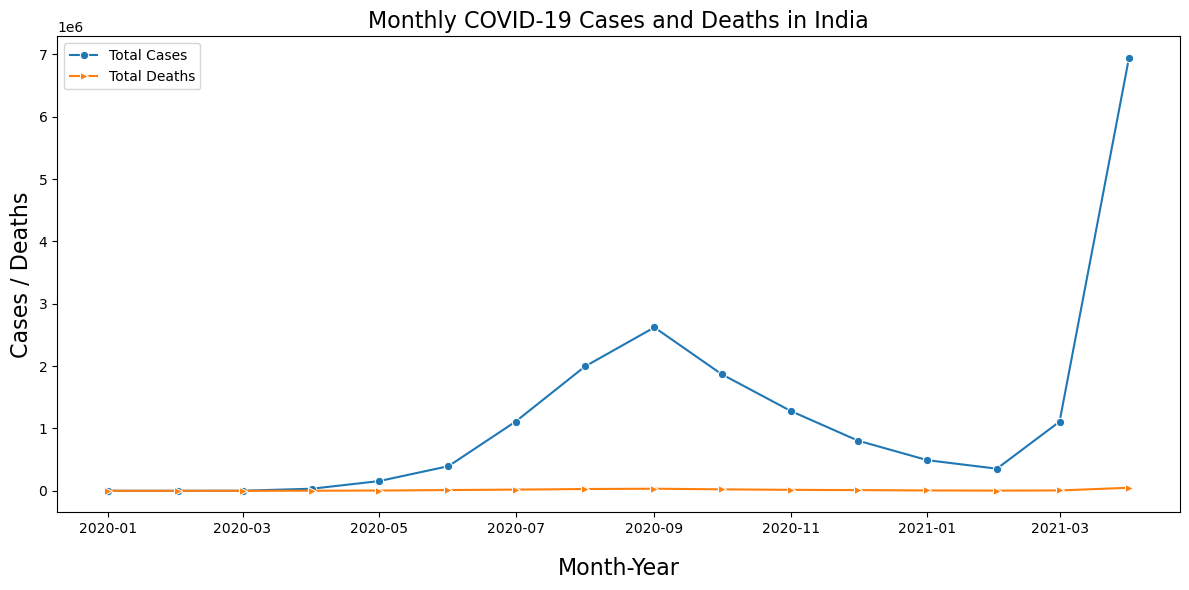

In [81]:
plt.figure(figsize=(12,6))
sns.lineplot(india_cases_deaths,
             x='Month-Year',
             y='Cases',
            marker='o',
            label='Total Cases')

sns.lineplot(india_cases_deaths,
             x='Month-Year',
             y='Deaths',
            marker='>',
            label='Total Deaths')

plt.title('Monthly COVID-19 Cases and Deaths in India',fontsize=16)
plt.xlabel('Month-Year',fontsize=16,labelpad=15)
plt.ylabel('Cases / Deaths',fontsize=16)
plt.tight_layout()
plt.show()

## Deaths due to Covid in India

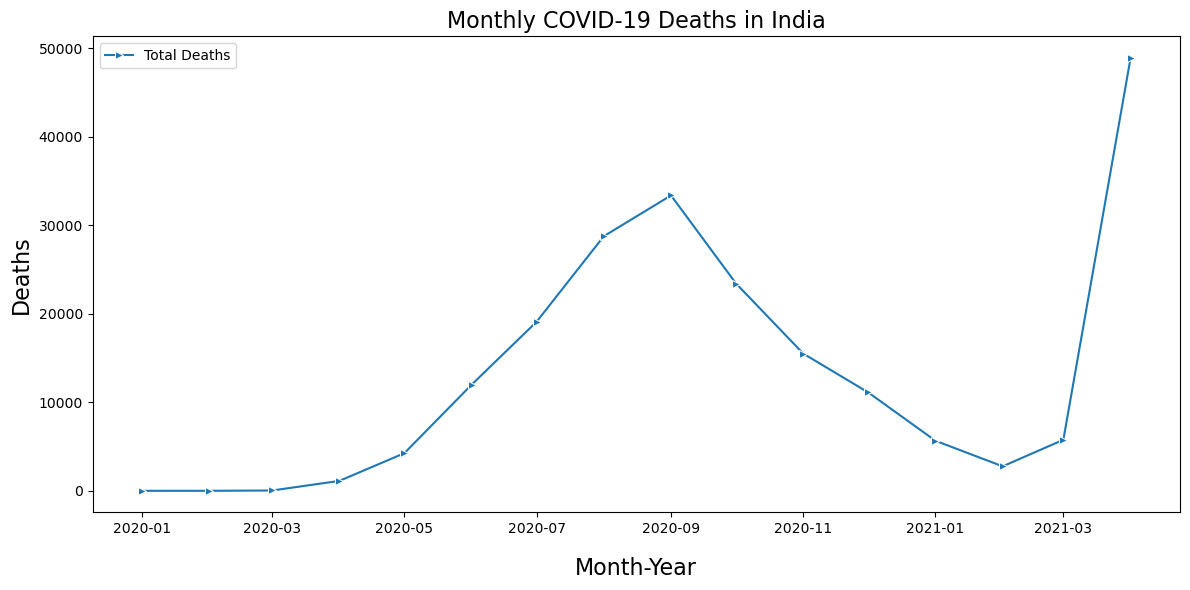

In [82]:
plt.figure(figsize=(12,6))
sns.lineplot(india_cases_deaths,
             x='Month-Year',
             y='Deaths',
            marker='>',
            label='Total Deaths')

plt.title('Monthly COVID-19 Deaths in India',fontsize=16)
plt.xlabel('Month-Year',fontsize=16,labelpad=15)
plt.ylabel('Deaths',fontsize=16)
plt.tight_layout()


# Covid-19 Tests and Vaccinations 

In [83]:
df2=pd.read_csv("CovidTestingVaccinations.csv")
df2

,iso_code,continent,location,date,new_tests,total_tests,total_tests_per_thousand,new_tests_per_thousand,new_tests_smoothed,new_tests_smoothed_per_thousand,...,gdp_per_capita,extreme_poverty,cardiovasc_death_rate,diabetes_prevalence,female_smokers,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index
0,AFG,Asia,Afghanistan,24-02-2020,NaN,NaN,NaN,NaN,NaN,NaN,...,1803.987,NaN,597.029,9.59,NaN,NaN,37.746,0.5,64.83,0.511
1,AFG,Asia,Afghanistan,25-02-2020,NaN,NaN,NaN,NaN,NaN,NaN,...,1803.987,NaN,597.029,9.59,NaN,NaN,37.746,0.5,64.83,0.511
2,AFG,Asia,Afghanistan,26-02-2020,NaN,NaN,NaN,NaN,NaN,NaN,...,1803.987,NaN,597.029,9.59,NaN,NaN,37.746,0.5,64.83,0.511
3,AFG,Asia,Afghanistan,27-02-2020,NaN,NaN,NaN,NaN,NaN,NaN,...,1803.987,NaN,597.029,9.59,NaN,NaN,37.746,0.5,64.83,0.511
4,AFG,Asia,Afghanistan,28-02-2020,NaN,NaN,NaN,NaN,NaN,NaN,...,1803.987,NaN,597.029,9.59,NaN,NaN,37.746,0.5,64.83,0.511
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85166,ZWE,Africa,Zimbabwe,26-04-2021,1495.0,484446.0,32.594,0.101,1722.0,0.116,...,1899.775,21.4,307.846,1.82,1.6,30.7,36.791,1.7,61.49,0.571
85167,ZWE,Africa,Zimbabwe,27-04-2021,2355.0,486801.0,32.753,0.158,1703.0,0.115,...,1899.775,21.4,307.846,1.82,1.6,30.7,36.791,1.7,61.49,0.571
85168,ZWE,Africa,Zimbabwe,28-04-2021,2025.0,488826.0,32.889,0.136,1716.0,0.115,...,1899.775,21.4,307.846,1.82,1.6,30.7,36.791,1.7,61.49,0.571
85169,ZWE,Africa,Zimbabwe,29-04-2021,NaN,NaN,NaN,NaN,NaN,NaN,...,1899.775,21.4,307.846,1.82,1.6,30.7,36.791,1.7,61.49,0.571


In [84]:
df2_cleaned = df2[(df2['continent'].notna()) & (df2['continent'] != '')]
df2_cleaned

,iso_code,continent,location,date,new_tests,total_tests,total_tests_per_thousand,new_tests_per_thousand,new_tests_smoothed,new_tests_smoothed_per_thousand,...,gdp_per_capita,extreme_poverty,cardiovasc_death_rate,diabetes_prevalence,female_smokers,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index
0,AFG,Asia,Afghanistan,24-02-2020,NaN,NaN,NaN,NaN,NaN,NaN,...,1803.987,NaN,597.029,9.59,NaN,NaN,37.746,0.5,64.83,0.511
1,AFG,Asia,Afghanistan,25-02-2020,NaN,NaN,NaN,NaN,NaN,NaN,...,1803.987,NaN,597.029,9.59,NaN,NaN,37.746,0.5,64.83,0.511
2,AFG,Asia,Afghanistan,26-02-2020,NaN,NaN,NaN,NaN,NaN,NaN,...,1803.987,NaN,597.029,9.59,NaN,NaN,37.746,0.5,64.83,0.511
3,AFG,Asia,Afghanistan,27-02-2020,NaN,NaN,NaN,NaN,NaN,NaN,...,1803.987,NaN,597.029,9.59,NaN,NaN,37.746,0.5,64.83,0.511
4,AFG,Asia,Afghanistan,28-02-2020,NaN,NaN,NaN,NaN,NaN,NaN,...,1803.987,NaN,597.029,9.59,NaN,NaN,37.746,0.5,64.83,0.511
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85166,ZWE,Africa,Zimbabwe,26-04-2021,1495.0,484446.0,32.594,0.101,1722.0,0.116,...,1899.775,21.4,307.846,1.82,1.6,30.7,36.791,1.7,61.49,0.571
85167,ZWE,Africa,Zimbabwe,27-04-2021,2355.0,486801.0,32.753,0.158,1703.0,0.115,...,1899.775,21.4,307.846,1.82,1.6,30.7,36.791,1.7,61.49,0.571
85168,ZWE,Africa,Zimbabwe,28-04-2021,2025.0,488826.0,32.889,0.136,1716.0,0.115,...,1899.775,21.4,307.846,1.82,1.6,30.7,36.791,1.7,61.49,0.571
85169,ZWE,Africa,Zimbabwe,29-04-2021,NaN,NaN,NaN,NaN,NaN,NaN,...,1899.775,21.4,307.846,1.82,1.6,30.7,36.791,1.7,61.49,0.571


In [85]:
tests_vaccinations = df2_cleaned.groupby(['location'])[['total_tests','total_vaccinations']].last().reset_index()
tests_vaccinations.columns = ['Country','Tests','Vaccinations']
tests_vaccinations

,Country,Tests,Vaccinations
0,Afghanistan,NaN,240000.0
1,Albania,610865.0,476903.0
2,Algeria,NaN,75000.0
3,Andorra,180633.0,26414.0
4,Angola,NaN,456349.0
...,...,...,...
205,Venezuela,NaN,250000.0
206,Vietnam,2482302.0,506435.0
207,Yemen,NaN,NaN
208,Zambia,1394900.0,26580.0


## Top 20 Countries that conducted Maximum Covid Tests

In [86]:
tests = tests_vaccinations.nlargest(20,'Tests')
tests = tests[['Country','Tests']]
tests = tests.reset_index(drop=True)
tests

,Country,Tests
0,United States,413502739.0
1,India,286392086.0
2,China,160000000.0
3,United Kingdom,151516625.0
4,Russia,129182804.0
5,Italy,58240981.0
6,Germany,55421229.0
7,Turkey,46996712.0
8,United Arab Emirates,43310259.0
9,Spain,39533769.0


## Top 20 Countries with maximum vaccinations done

In [87]:
vaccinations = tests_vaccinations[['Country','Vaccinations']]
vaccinations = vaccinations.nlargest(20,'Vaccinations')
vaccinations = vaccinations.reset_index(drop=True)
vaccinations

,Country,Vaccinations
0,China,265064000.0
1,United States,240159677.0
2,India,151998107.0
3,United Kingdom,48748962.0
4,Brazil,42698862.0
5,Germany,28774580.0
6,Turkey,22816891.0
7,France,21518866.0
8,Indonesia,20068537.0
9,Italy,19949067.0


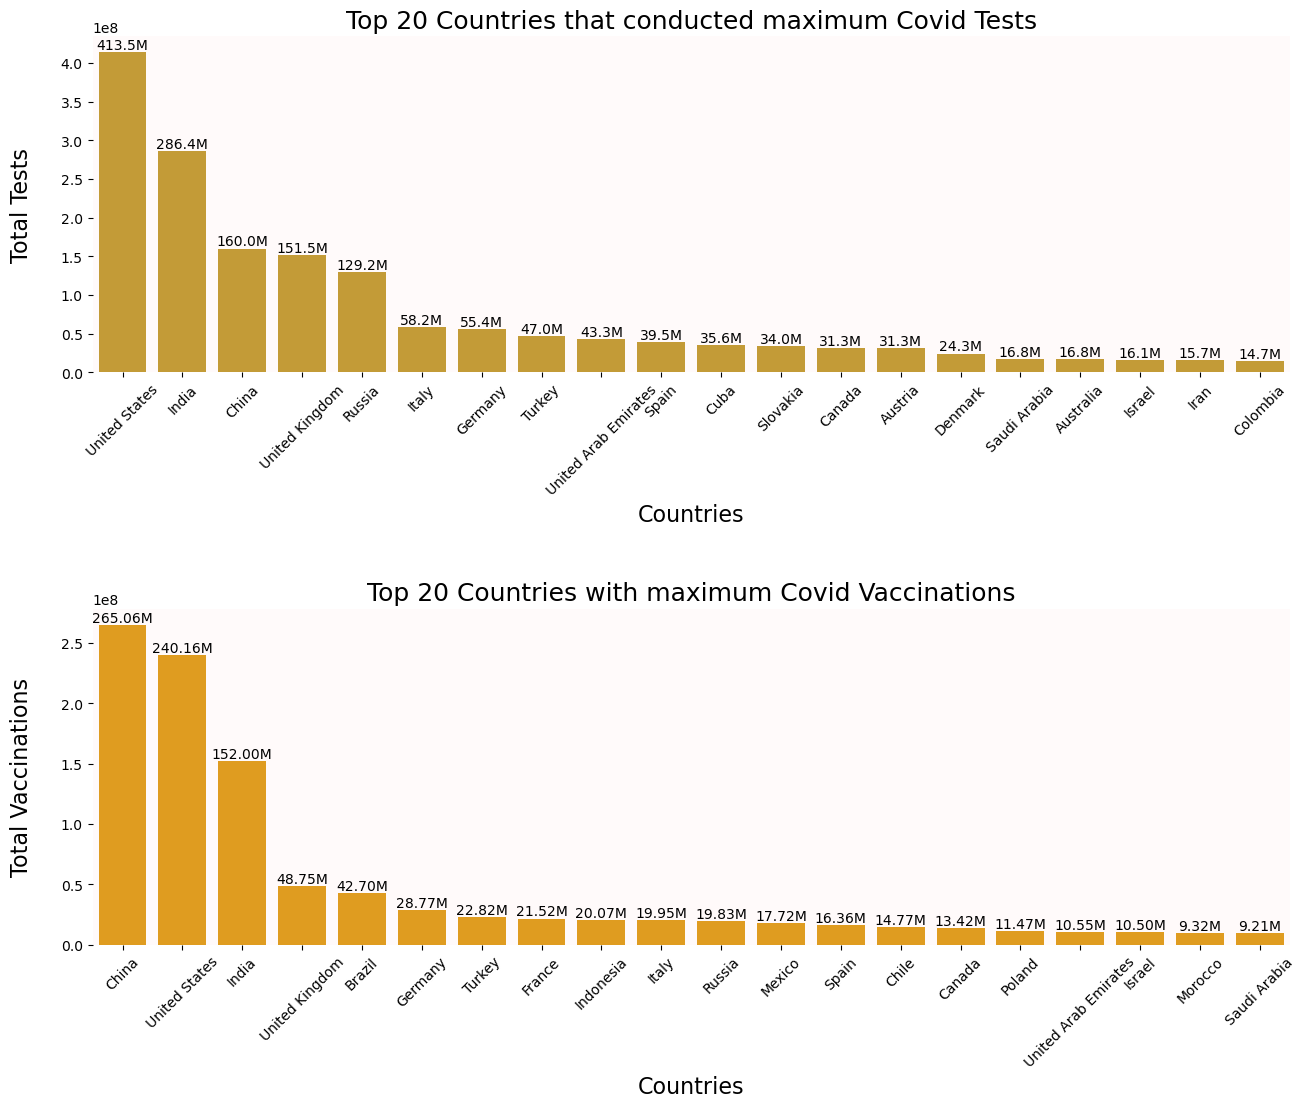

In [89]:
fig, axes = plt.subplots(nrows=2,ncols=1,figsize=(14, 12))

bars = sns.barplot(ax=axes[0],
                   data=tests,
                   x='Country',
                   y='Tests',
                   color='goldenrod')
axes[0].tick_params(axis='x',rotation=45)
axes[0].set_xlabel('Countries',fontsize=16)
axes[0].set_ylabel('Total Tests',fontsize=16,labelpad=20)
axes[0].set_title('Top 20 Countries that conducted maximum Covid Tests',fontsize=18)
axes[0].set_facecolor('snow')

for bar in bars.patches:
    height=bar.get_height()
    bars.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height/1e6:.1f}M',
        ha='center',
        va='bottom'
    )

bars= sns.barplot(ax=axes[1],
                  data=vaccinations,
                  x='Country',
                  y='Vaccinations',
                  color='orange')

axes[1].tick_params(axis='x',rotation=45)
axes[1].set_xlabel('Countries',fontsize=16)
axes[1].set_ylabel('Total Vaccinations',fontsize=16,labelpad=20)
axes[1].set_title('Top 20 Countries with maximum Covid Vaccinations',fontsize=18)
axes[1].set_facecolor('snow')

for bar in bars.patches:
    height=bar.get_height()
    bars.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height/1e6:.2f}M',
        ha='center',
        va='bottom'
    )

for ax in axes:
    for spine in ['top', 'right', 'left', 'bottom']:
        ax.spines[spine].set_visible(False)

plt.tight_layout(pad=4) 

## Tests and Vaccinations in continents

In [90]:
continent_tests_vaccinations = df2_cleaned.groupby(['location'])[['continent','total_tests','total_vaccinations']].last().reset_index()
continent_tests_vaccinations

,location,continent,total_tests,total_vaccinations
0,Afghanistan,Asia,NaN,240000.0
1,Albania,Europe,610865.0,476903.0
2,Algeria,Africa,NaN,75000.0
3,Andorra,Europe,180633.0,26414.0
4,Angola,Africa,NaN,456349.0
...,...,...,...,...
205,Venezuela,South America,NaN,250000.0
206,Vietnam,Asia,2482302.0,506435.0
207,Yemen,Asia,NaN,NaN
208,Zambia,Africa,1394900.0,26580.0


In [91]:
continent_tests_vaccinations = continent_tests_vaccinations.groupby(['continent'])[['total_tests','total_vaccinations']].sum().reset_index()
continent_tests_vaccinations.columns = ['Continents','Tests','Vaccinations']
continent_tests_vaccinations

,Continents,Tests,Vaccinations
0,Africa,32267468.0,17827619.0
1,Asia,736598941.0,536861818.0
2,Europe,652459953.0,224757173.0
3,North America,493789008.0,276667743.0
4,Oceania,18864994.0,2487869.0
5,South America,51062308.0,75731252.0


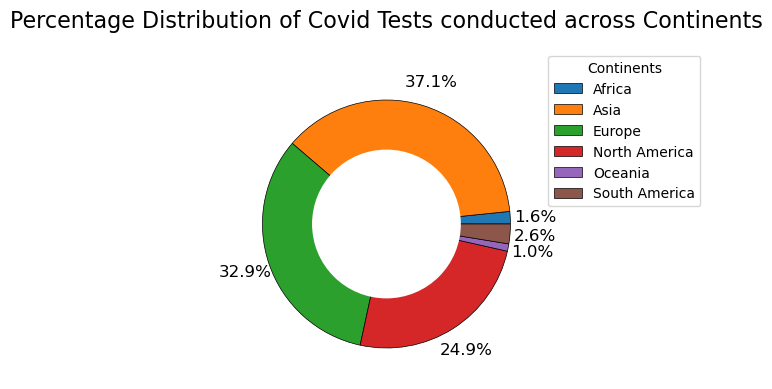

In [92]:
labels=continent_tests_vaccinations['Continents']
plt.figure(figsize=(4,6))
wedges, texts, autotexts = plt.pie(continent_tests_vaccinations['Tests'],
                                   autopct='%1.1f%%',
                                   wedgeprops={'edgecolor':'black','linewidth':0.5},
                                   pctdistance=1.2
                                  )

centre_circle = plt.Circle((0, 0), 0.60, fc='white')
plt.gca().add_artist(centre_circle)

for autotext in autotexts:
    autotext.set_fontsize(12)

plt.legend(wedges, 
           labels,
           title='Continents', 
           loc='center left', 
           bbox_to_anchor=(1, 0.8))

plt.title('Percentage Distribution of Covid Tests conducted across Continents',fontsize=16,pad=30)

plt.show()

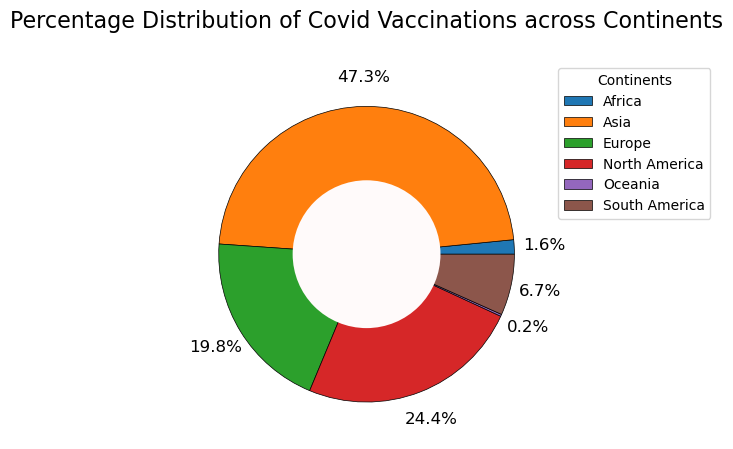

In [93]:
labels=continent_tests_vaccinations['Continents']

wedges,texts,autotexts=plt.pie(continent_tests_vaccinations['Vaccinations'],
                               autopct='%1.1f%%',
                              pctdistance=1.2,
                               wedgeprops={'edgecolor':'black','linewidth':0.5}
                              )

centre_circle=plt.Circle((0,0),0.5,fc='snow')
plt.gca().add_artist(centre_circle)

for autotext in autotexts:
    autotext.set_fontsize(12)

plt.legend(labels,
           title='Continents', 
           loc='center left',
           bbox_to_anchor=(1, 0.8))
plt.title('Percentage Distribution of Covid Vaccinations across Continents',fontsize=16,pad=30)

plt.show()

## Tests and Vaccinations across Asia

In [94]:
asia_df2 = df2[df2['continent'] == 'Asia']
asia_df2

,iso_code,continent,location,date,new_tests,total_tests,total_tests_per_thousand,new_tests_per_thousand,new_tests_smoothed,new_tests_smoothed_per_thousand,...,gdp_per_capita,extreme_poverty,cardiovasc_death_rate,diabetes_prevalence,female_smokers,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index
0,AFG,Asia,Afghanistan,24-02-2020,NaN,NaN,NaN,NaN,NaN,NaN,...,1803.987,NaN,597.029,9.59,NaN,NaN,37.746,0.5,64.83,0.511
1,AFG,Asia,Afghanistan,25-02-2020,NaN,NaN,NaN,NaN,NaN,NaN,...,1803.987,NaN,597.029,9.59,NaN,NaN,37.746,0.5,64.83,0.511
2,AFG,Asia,Afghanistan,26-02-2020,NaN,NaN,NaN,NaN,NaN,NaN,...,1803.987,NaN,597.029,9.59,NaN,NaN,37.746,0.5,64.83,0.511
3,AFG,Asia,Afghanistan,27-02-2020,NaN,NaN,NaN,NaN,NaN,NaN,...,1803.987,NaN,597.029,9.59,NaN,NaN,37.746,0.5,64.83,0.511
4,AFG,Asia,Afghanistan,28-02-2020,NaN,NaN,NaN,NaN,NaN,NaN,...,1803.987,NaN,597.029,9.59,NaN,NaN,37.746,0.5,64.83,0.511
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84350,YEM,Asia,Yemen,26-04-2021,NaN,NaN,NaN,NaN,NaN,NaN,...,1479.147,18.8,495.003,5.35,7.6,29.2,49.542,0.7,66.12,0.470
84351,YEM,Asia,Yemen,27-04-2021,NaN,NaN,NaN,NaN,NaN,NaN,...,1479.147,18.8,495.003,5.35,7.6,29.2,49.542,0.7,66.12,0.470
84352,YEM,Asia,Yemen,28-04-2021,NaN,NaN,NaN,NaN,NaN,NaN,...,1479.147,18.8,495.003,5.35,7.6,29.2,49.542,0.7,66.12,0.470
84353,YEM,Asia,Yemen,29-04-2021,NaN,NaN,NaN,NaN,NaN,NaN,...,1479.147,18.8,495.003,5.35,7.6,29.2,49.542,0.7,66.12,0.470


In [95]:
asia_tests_vaccinations = asia_df2.groupby(['location'])[['total_tests','total_vaccinations']].last().reset_index()
asia_tests_vaccinations.columns = ['Country','Tests','Vaccinations']
asia_tests_vaccinations

,Country,Tests,Vaccinations
0,Afghanistan,NaN,240000.0
1,Armenia,979060.0,565.0
2,Azerbaijan,3229867.0,1488218.0
3,Bahrain,4079066.0,1235170.0
4,Bangladesh,5444255.0,8625350.0
5,Bhutan,698560.0,480422.0
6,Brunei,NaN,10715.0
7,Cambodia,NaN,2284788.0
8,China,160000000.0,265064000.0
9,Georgia,4156000.0,45338.0


In [96]:
asia_tests = asia_tests_vaccinations.nlargest(20,'Tests')
asia_tests = asia_tests[['Country','Tests']]
asia_tests = asia_tests.reset_index(drop=True)   
asia_tests

,Country,Tests
0,India,286392086.0
1,China,160000000.0
2,Turkey,46996712.0
3,United Arab Emirates,43310259.0
4,Saudi Arabia,16838619.0
5,Israel,16101570.0
6,Iran,15693870.0
7,Hong Kong,12935888.0
8,Pakistan,11788126.0
9,Japan,11154934.0


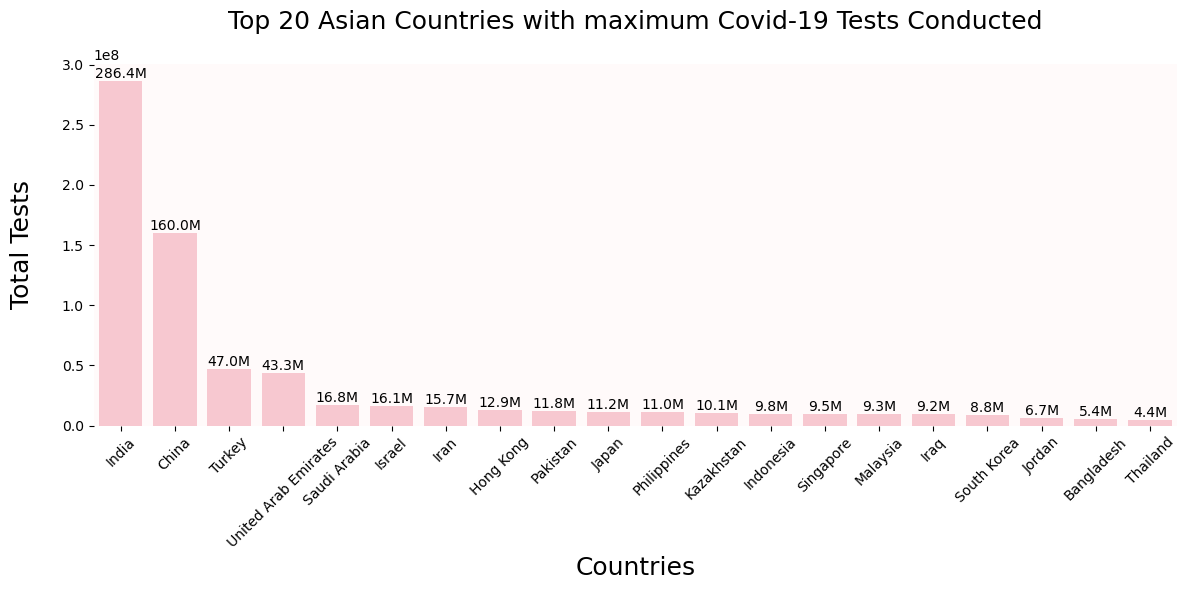

In [104]:
plt.figure(figsize=(12,6))

bars=sns.barplot(asia_tests,
            x='Country',
            y='Tests',color="Pink")

ax=plt.gca()
for spine in ['top','right','bottom','left']:
    ax.spines[spine].set_visible(False)

ax.set_facecolor('snow')

plt.title("Top 20 Asian Countries with maximum Covid-19 Tests Conducted",fontsize=18,pad=25)
plt.xlabel("Countries",fontsize=18)
plt.ylabel("Total Tests",fontsize=18,labelpad=20)
plt.xticks(rotation=45)

plt.tight_layout()
for bar in bars.patches:
    height = bar.get_height()
    bars.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height/1e6:.1f}M',  
        ha='center',
        va='bottom',
        fontsize=10
    )


## Top 20 Asian countries with maximum vaccinations held

In [105]:
asia_vaccinations = asia_tests_vaccinations.nlargest(20,'Vaccinations')
asia_vaccinations = asia_vaccinations[['Country','Vaccinations']]
asia_vaccinations = asia_vaccinations.reset_index(drop=True)
asia_vaccinations

,Country,Vaccinations
0,China,265064000.0
1,India,151998107.0
2,Turkey,22816891.0
3,Indonesia,20068537.0
4,United Arab Emirates,10547584.0
5,Israel,10497355.0
6,Saudi Arabia,9214983.0
7,Bangladesh,8625350.0
8,South Korea,3554402.0
9,Japan,3489719.0


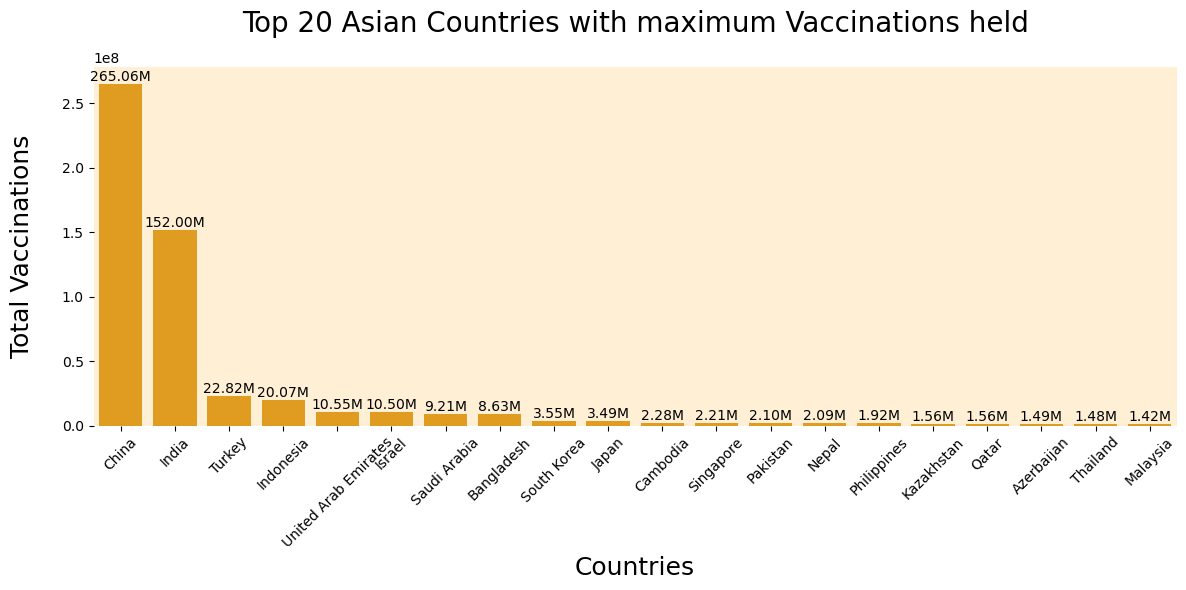

In [115]:
plt.figure(figsize=(12,6))

bars=sns.barplot(asia_vaccinations,
             x='Country',
             y='Vaccinations',
            color='orange')

ax=plt.gca()
for spine in ['top','right','left','bottom']:
    ax.spines[spine].set_visible(False)

ax.set_facecolor('papayawhip')

plt.title('Top 20 Asian Countries with maximum Vaccinations held',fontsize=20,pad=25)
plt.xlabel('Countries',fontsize=18)
plt.ylabel('Total Vaccinations',fontsize=18,labelpad=20)
plt.xticks(rotation=45)
plt.tight_layout()

for bar in bars.patches:
    height=bar.get_height()
    bars.text(
        bar.get_x()+bar.get_width() /2,
        height,
        f'{height/1e6:.2f}M',  
        ha='center',
        va='bottom',
        fontsize=10
    )